In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import pandas as pd

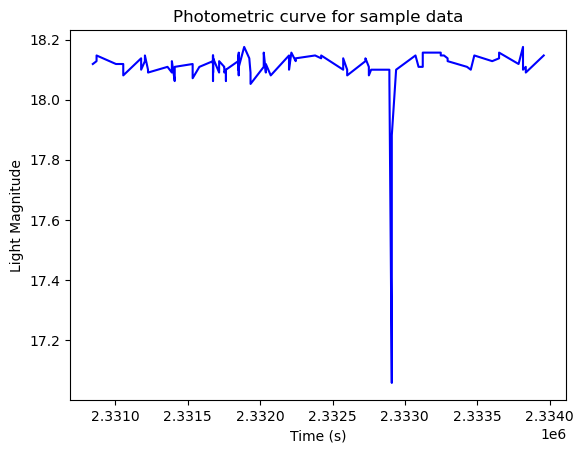

In [32]:
# MAIN SEQUENCE

sample_curve = pd.read_csv(r"caitlinbegbie CORONA melina gaia_mainseq\1.01jds_new_Gaia21ack.csv")
#good_idx = np.where(sample_curve.iloc[:, 16] == 0)
#t = sample_curve.iloc[:, 0].to_numpy()
#mag = sample_curve.iloc[:, 7].to_numpy()
t = sample_curve["JD (TCB)"].to_numpy()
mag = sample_curve["avg Mag"].to_numpy()

plt.title("Photometric curve for sample data")
plt.plot(t, mag, label="Data", color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Light Magnitude")
#plt.ylim((-50, 100))
plt.show()

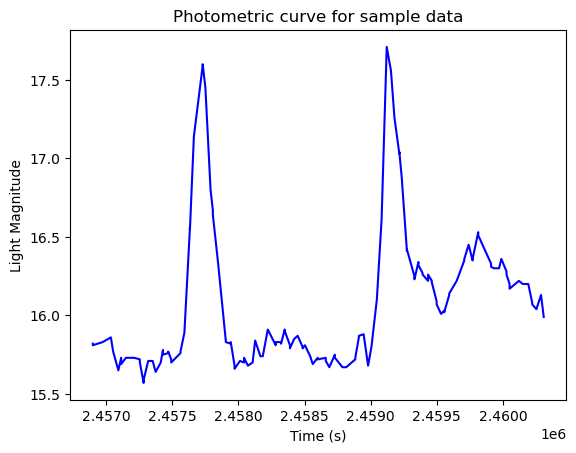

In [22]:
# RCB GAIA

sample_curve = pd.read_csv(r"rcb data\gaia rcbs 3\noisey1_new_Gaia20fay.csv")
sample_curve["avg Mag"] = pd.to_numeric(sample_curve["avg Mag"], errors="coerce")
valid_data = sample_curve.dropna(subset=["avg Mag"])

t = valid_data["JD (TCB)"].to_numpy()
mag = valid_data["avg Mag"].to_numpy()

plt.title("Photometric curve for sample data")
plt.plot(t, mag, label="Data", color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Light Magnitude")
plt.show()

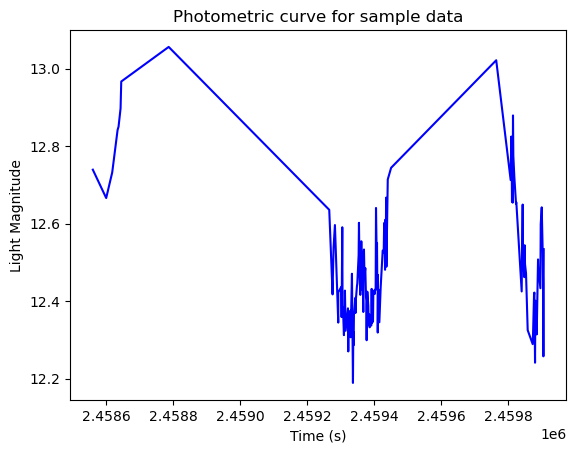

In [29]:
# RCB ZENODO

sample_curve = pd.read_csv(r"rcb data\Zenodo rcbs fixed\noisey1_lc_wise-toi-248.csv")
sample_curve["mags"] = pd.to_numeric(sample_curve["mags"], errors="coerce") 
valid_data = sample_curve.dropna(subset=["mags"])

valid_data = valid_data.sort_values(by="jds")
t = valid_data["jds"].to_numpy()
mag = valid_data["mags"].to_numpy()

plt.title("Photometric curve for sample data")
plt.plot(t, mag, label="Data", color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Light Magnitude")
plt.show()

In [10]:
"""from astropy.table import Table
sample_curve = Table.read("main sequence/2jds light_curve_44513.csv", format='ascii')

good_idx = np.where(sample_curve['col17'] == 0)
print(np.unique(sample_curve[good_idx]['col17']))
t = np.array(sample_curve[good_idx]['col1'])
mag = np.array(sample_curve[good_idx]['col8'])
print(t,mag)
#t = sample_curve["jds"].to_numpy()
#mag = sample_curve["mags"].to_numpy()

plt.title("Photometric curve for sample data")
plt.plot(t, mag, label="Data", color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Light Magnitude")
plt.ylim((-50, 100))
plt.show()"""

'from astropy.table import Table\nsample_curve = Table.read("main sequence/2jds light_curve_44513.csv", format=\'ascii\')\n\ngood_idx = np.where(sample_curve[\'col17\'] == 0)\nprint(np.unique(sample_curve[good_idx][\'col17\']))\nt = np.array(sample_curve[good_idx][\'col1\'])\nmag = np.array(sample_curve[good_idx][\'col8\'])\nprint(t,mag)\n#t = sample_curve["jds"].to_numpy()\n#mag = sample_curve["mags"].to_numpy()\n\nplt.title("Photometric curve for sample data")\nplt.plot(t, mag, label="Data", color="blue")\nplt.xlabel("Time (s)")\nplt.ylabel("Light Magnitude")\nplt.ylim((-50, 100))\nplt.show()'

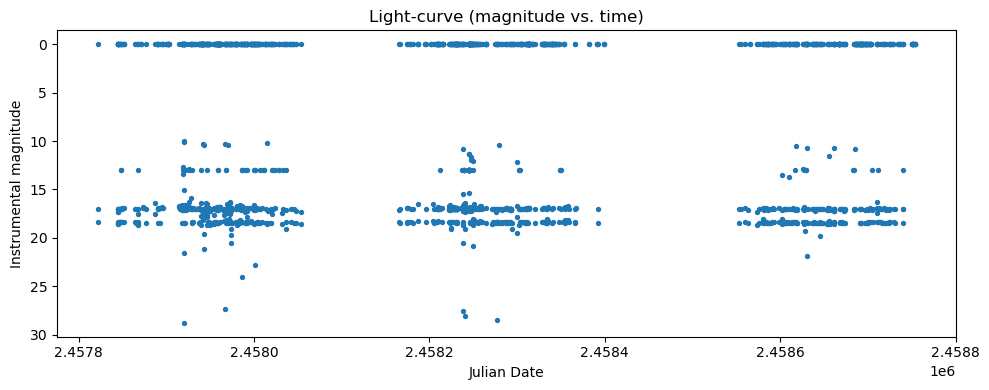

In [30]:
import re
from pathlib import Path
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# ✅ EDIT THIS to point at your light-curve CSV
FILENAME = Path("main sequence/1.4367jds light_curve_43000.csv")
# -----------------------------------------------------------

def numeric_token(token: str):
    """Return the leading float in *token*, or None if none found."""
    m = re.match(r"[-+]?\d*\.\d+|\d+", token)
    return float(m.group()) if m else None

jd, mag = [], []

with FILENAME.open() as fh:
    for ln in fh:
        if not ln.strip() or ln.lstrip().startswith("#"):
            continue                         # skip blanks / comments

        tokens = ln.split(",")

        # --- time stamp ----------------------------------------------------
        t0 = numeric_token(tokens[0])        # Julian Date
        if t0 is None:
            continue

        # --- look for a plausible magnitude -------------------------------
        m_val = None
        for tok in tokens[1:]:
            num = numeric_token(tok)
            if num is not None and 10.0 < num < 30.0:
                m_val = num
                break

        # sometimes the magnitude lives in column 7 (index 7)
        if m_val is None and len(tokens) > 7:
            m_val = numeric_token(tokens[7])

        if m_val is None:
            continue                         # give up on this line

        jd.append(t0)
        mag.append(m_val)

# ---------------------------  Plot  ----------------------------------------
plt.figure(figsize=(10, 4))
plt.scatter(jd, mag, s=8)
plt.gca().invert_yaxis()        # smaller mag = brighter
plt.xlabel("Julian Date")
plt.ylabel("Instrumental magnitude")
plt.title("Light-curve (magnitude vs. time)")
plt.tight_layout()
plt.show()
